In [3]:
# If TensorFlow is missing, run this once:
# !pip install tensorflow

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Make results more reproducible
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# Load the dataset. Keep the CSV in the same folder as this notebook.
file_path = 'data (1).csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "Place 'data (1).csv' in the same folder as this notebook, then run again."
    )

df = pd.read_csv(file_path)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# Remove the ID and any completely empty columns
df = df.drop(columns=['id'], errors='ignore')
df = df.dropna(axis=1, how='all')

# Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Label-encode the text target: B and M become 0 and 1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)

print('Classes:', list(label_encoder.classes_))
print('Number of classes:', n_classes)
print('Number of features:', X.shape[1])

Classes: ['B', 'M']
Number of classes: 2
Number of features: 30


In [6]:
# Split into 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale using training data only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Training shape: (455, 30)
Test shape: (114, 30)


In [7]:
# Required ANN architecture
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,554 (6.07 KB)

 Trainable params: 1,554 (6.07 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train for 30 epochs; 20% of the training split is used for validation
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5549 - loss: 0.6713 - val_accuracy: 0.6484 - val_loss: 0.5661
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8819 - loss: 0.4204 - val_accuracy: 0.8901 - val_loss: 0.3684
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9396 - loss: 0.2941 - val_accuracy: 0.9451 - val_loss: 0.2654
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.2198 - val_accuracy: 0.9451 - val_loss: 0.2067
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9560 - loss: 0.1748 - val_accuracy: 0.9451 - val_loss: 0.1734
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1464 - val_accuracy: 0.9451 - val_loss: 0.1531
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9643 - loss: 0.1272 - val_accuracy: 0.9670 - val_loss: 0.1395
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.1129 - val_accuracy: 0.9670 - val_loss

In [9]:
# Evaluate the final model on data it did not train on
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)

print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)')
print(f'Accuracy check: {accuracy_score(y_test, y_pred):.4f}')

Final test loss: 0.0646
Final test accuracy: 0.9912 (99.12%)
Accuracy check: 0.9912


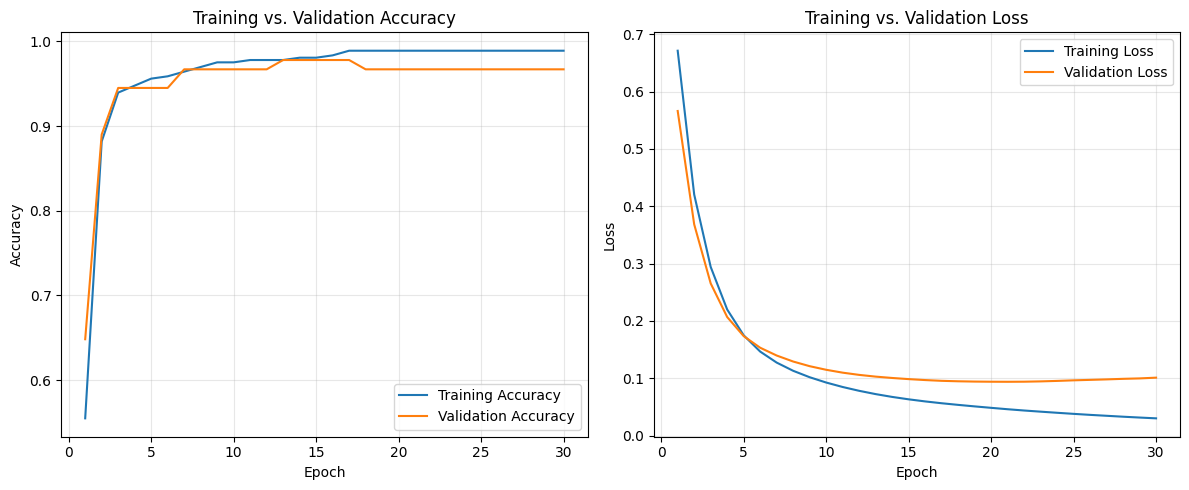

In [10]:
# Plot training and validation accuracy and loss
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Why Softmax instead of one Sigmoid neuron?

Softmax gives one probability for every class and makes all class probabilities sum to 1, so the model can choose among mutually exclusive classes. A single Sigmoid neuron produces only one independent probability and does not provide a separate output for each class.